In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
iris = sns.load_dataset("iris")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# Data handling

- create groupings/classes useful for pie charts

In [3]:
iris["SepalLengthClass"] = pd.cut(iris.sepal_length, bins=[0, 5, 6.5, 10], labels=["short", "medium", "long"])
iris["SepalWidthClass"] = pd.cut(iris.sepal_width, bins=[0, 2.7, 3.4, 6], labels=["thin", "normal", "thick"])
iris

,sepal_length,sepal_width,petal_length,petal_width,species,SepalLengthClass,SepalWidthClass
0,5.1,3.5,1.4,0.2,setosa,medium,thick
1,4.9,3.0,1.4,0.2,setosa,short,normal
2,4.7,3.2,1.3,0.2,setosa,short,normal
3,4.6,3.1,1.5,0.2,setosa,short,normal
4,5.0,3.6,1.4,0.2,setosa,short,thick
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,long,normal
146,6.3,2.5,5.0,1.9,virginica,medium,thin
147,6.5,3.0,5.2,2.0,virginica,medium,normal
148,6.2,3.4,5.4,2.3,virginica,medium,normal


- create crosstabulation for values vs values

In [4]:
iris1 = pd.crosstab(iris["SepalLengthClass"], iris["SepalWidthClass"])
iris1

SepalWidthClass,thin,normal,thick
SepalLengthClass,,,
short,5,22,5
medium,26,45,17
long,2,25,3


- transpose the crosstabulation

In [5]:
iris2 = iris1.transpose()
iris2

SepalLengthClass,short,medium,long
SepalWidthClass,,,
thin,5,26,2
normal,22,45,25
thick,5,17,3


- add summation columns

In [6]:
iris1["AllFlowers"] = iris1[iris1.columns].sum(axis=1)
iris2["AllFlowers"] = iris2[iris2.columns].sum(axis=1)
iris1, iris2

(SepalWidthClass   thin  normal  thick  AllFlowers
 SepalLengthClass                                 
 short                5      22      5          32
 medium              26      45     17          88
 long                 2      25      3          30,
 SepalLengthClass  short  medium  long  AllFlowers
 SepalWidthClass                                  
 thin                  5      26     2          33
 normal               22      45    25          92
 thick                 5      17     3          25)

# Matplotlib

## Basic pie chart

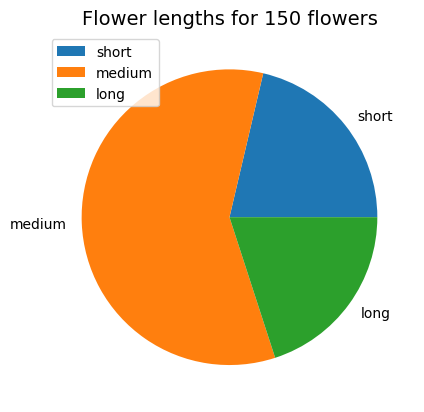

In [7]:
ax = iris1.plot.pie(y="AllFlowers")
ax.set_title("Flower lengths for 150 flowers", fontsize=14)
ax.set_ylabel("")
plt.legend(loc="upper left")
plt.show()

***

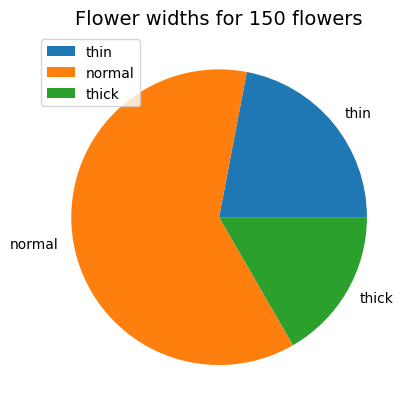

In [8]:
ax = iris2.plot.pie(y="AllFlowers")
ax.set_title("Flower widths for 150 flowers", fontsize=14)
ax.set_ylabel("")
plt.legend(loc="upper left")
plt.show()

***

## Mutliple pie chart

SepalWidthClass,thin,normal,thick,AllFlowers
SepalLengthClass,,,,
short,5,22,5,32
medium,26,45,17,88
long,2,25,3,30


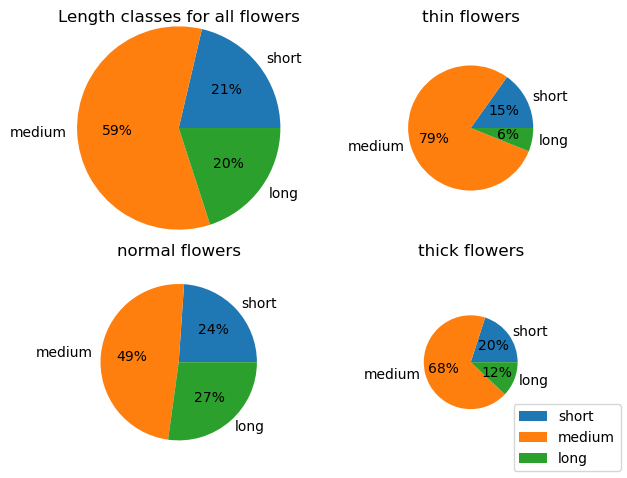

In [9]:
fig, ((pie1, pie2),(pie3, pie4)) = plt.subplots(2, 2)
iris1.plot.pie(y="AllFlowers", legend=False, ylabel="", title="Length classes for all flowers", autopct="%.0f%%", radius=1.3, ax=pie1)
iris1.plot.pie(y="thin", legend=False, ylabel="", title="thin flowers", autopct="%.0f%%", radius = 0.8, ax=pie2)
iris1.plot.pie(y="normal", legend=False, ylabel="", title="normal flowers", autopct="%.0f%%", radius = 1.0, ax=pie3)
iris1.plot.pie(y="thick", legend=False, ylabel="", title="thick flowers", autopct="%.0f%%", radius = 0.6, ax=pie4)
fig.legend(["short", "medium", "long"], loc="lower right")
fig.tight_layout()
plt.show
iris1

## Editing options

- `explode` parameter

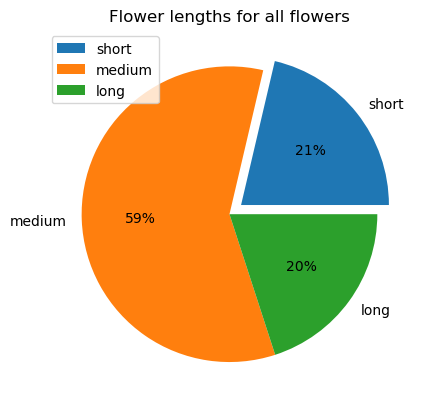

In [10]:
explodeDist = (0.1, 0, 0)
ax = iris1.plot.pie(y="AllFlowers", autopct="%.0f%%", explode=explodeDist)
ax.set_title("Flower lengths for all flowers")
ax.set_ylabel("")
plt.legend(loc="upper left")
plt.show()

***

- shadows can be added to the pie plot
- labels edited
- the `autopct` can be made to plot values instead of percentages

In [11]:
iris1

SepalWidthClass,thin,normal,thick,AllFlowers
SepalLengthClass,,,,
short,5,22,5,32
medium,26,45,17,88
long,2,25,3,30


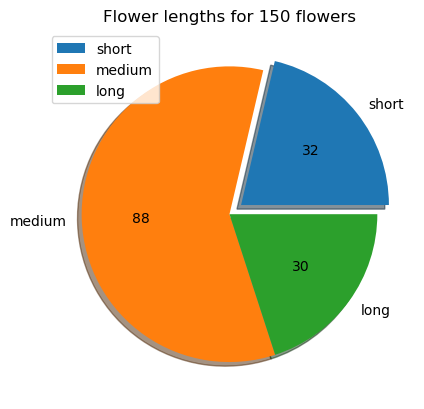

In [14]:
labelList = iris1.index.values.tolist()
values = iris1["AllFlowers"]
explodeDist = (0.1, 0, 0)
ax = iris1.plot.pie(y="AllFlowers", autopct=lambda x: '{:.0f}'.format(x*values.sum()/100), shadow=True, labels=labelList, explode=explodeDist)
ax.set_title("Flower lengths for 150 flowers")
ax.set_ylabel("")
plt.legend(loc="upper left")
plt.show()

**What `autopct` does**<br>
The `autopct` parameter in `plot.pie()` is used to format the labels that appear on each slice.<br>
Normally it shows percentages.<br>

**How the `lambda` function works**<br>
This lambda function receives one argument: `x`, which is the **percentage** of the slice. 
What happens inside:
1. `x` is the percentage of the slice
2. `values.sum()` is the total number of flowers
3. `x * values.sum() / 100` converts the percentage into an **absolute count**
4. `'{:.0f}'.format(...)` formats the result as a **whole number**  

***

- colour palettes can be collected from Seaborn and used with Matplotlib.

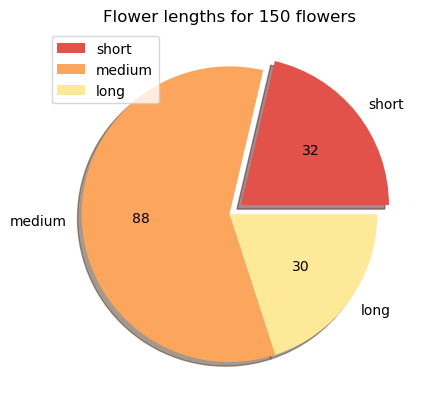

In [16]:
snsColours = sns.color_palette("Spectral")[0:3]
labelList = iris1.index.values.tolist()
values = iris1["AllFlowers"]
explodeDist = (0.1, 0, 0)
ax = iris1.plot.pie(y="AllFlowers",
                    autopct=lambda x: '{:.0f}'.format(x*values.sum()/100),
                    colors = snsColours,
                    shadow=True,
                    labels=labelList,
                    explode=explodeDist)
ax.set_title("Flower lengths for 150 flowers")
ax.set_ylabel("")
plt.legend(loc="upper left")
plt.show()